In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model


In [8]:
data = pd.read_csv("IBM.csv")

data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13642 entries, 0 to 13641
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  13642 non-null  int64         
 1   Date        13642 non-null  datetime64[us]
 2   Open_IBM    13642 non-null  float64       
 3   High_IBM    13642 non-null  float64       
 4   Low_IBM     13642 non-null  float64       
 5   Close_IBM   13642 non-null  float64       
 6   Volume_IBM  13642 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 746.2 KB


In [14]:
returns = 100 * np.log(data["Close_IBM"]).diff().dropna().reset_index(drop=True)
dates = data.loc[data["Close_IBM"].shift(1).notna(), "Date"].reset_index(drop=True)

test_size = 30
validation_size = 60

train = returns.iloc[:-test_size - validation_size]
validation = returns.iloc[-test_size - validation_size:-test_size]
test = returns.iloc[-test_size:]

specifications = [
    (p, q, dist)
    for p in range(1, 4)
    for q in range(1, 4)
    for dist in ["normal", "t"]
]

fits = []

for p, q, dist in specifications:
    model = arch_model(
        train,
        mean="Constant",
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
        rescale=False,
    )
    fit = model.fit(disp="off")
    fits.append((fit.bic, p, q, dist, fit))

fits.sort(key=lambda x: x[0])
_, p, q, dist, fit = fits[0]

print(f"Selected GARCH({p},{q}) with {dist} innovations")
print(f"Training BIC: {fit.bic:.3f}")

forecast = fit.forecast(
    horizon=validation_size + test_size,
    reindex=False,
)

variance_forecast = forecast.variance.iloc[-1].to_numpy()
volatility_forecast = np.sqrt(variance_forecast)

validation_variance = variance_forecast[:validation_size]
test_variance = variance_forecast[validation_size:]

validation_volatility = volatility_forecast[:validation_size]
test_volatility = volatility_forecast[validation_size:]

validation_squared_returns = validation.to_numpy() ** 2
test_squared_returns = test.to_numpy() ** 2

def qlike(realized, forecast):
    return np.mean(
        np.log(forecast) + realized / forecast
    )

print(f"Validation QLIKE: {qlike(validation_squared_returns, validation_variance):.3f}")
print(f"Test QLIKE: {qlike(test_squared_returns, test_variance):.3f}")

validation_dates = dates.iloc[-test_size - validation_size:-test_size]
test_dates = dates.iloc[-test_size:]



Selected GARCH(1,1) with t innovations
Training BIC: 47458.345
Validation QLIKE: 3.002
Test QLIKE: 3.843


Test volatility MSE: 3.013230


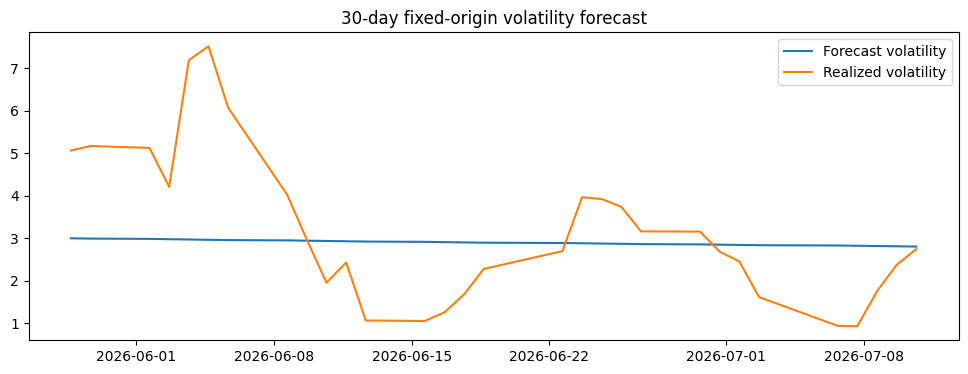

,Date,Forecast volatility,Realized volatility
0,2026-05-28 16:00:00,3.000027,5.063924
1,2026-05-29 16:00:00,2.992888,5.167736
2,2026-06-01 16:00:00,2.985782,5.124139
3,2026-06-02 16:00:00,2.978707,4.206568
4,2026-06-03 16:00:00,2.971665,7.184130
5,2026-06-04 16:00:00,2.964655,7.511954
6,2026-06-05 16:00:00,2.957677,6.067803
7,2026-06-08 16:00:00,2.950731,4.026470
8,2026-06-09 16:00:00,2.943817,2.968932
9,2026-06-10 16:00:00,2.936934,1.956505


In [15]:
final_train = returns.iloc[:-test_size]

final_model = arch_model(
    final_train,
    mean="Constant",
    vol="GARCH",
    p=p,
    q=q,
    dist=dist,
    rescale=False,
).fit(disp="off")

test_forecast = final_model.forecast(
    horizon=test_size,
    reindex=False,
)

test_variance = test_forecast.variance.iloc[-1].to_numpy()
test_volatility = np.sqrt(test_variance)

test_realized_volatility = (
    returns.rolling(5).std().iloc[-test_size:]
)

test_mse = np.mean(
    (test_volatility - test_realized_volatility.to_numpy()) ** 2
)

print(f"Test volatility MSE: {test_mse:.6f}")

plt.figure(figsize=(12, 4))
plt.plot(test_dates, test_volatility, label="Forecast volatility")
plt.plot(
    test_dates,
    test_realized_volatility,
    label="Realized volatility",
)
plt.legend()
plt.title("30-day fixed-origin volatility forecast")
plt.show()

test_forecast_table = pd.DataFrame({
    "Date": test_dates.to_numpy(),
    "Forecast volatility": test_volatility,
    "Realized volatility": test_realized_volatility.to_numpy(),
})

test_forecast_table

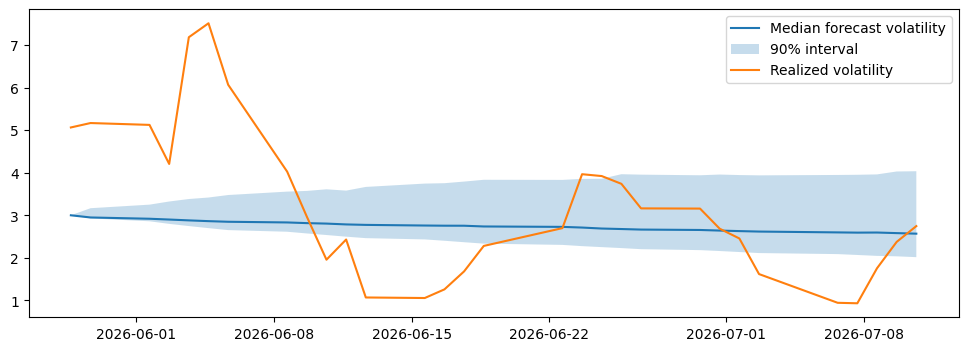

In [17]:
simulated_forecast = final_model.forecast(
    horizon=test_size,
    method="simulation",
    simulations=2000,
    reindex=False,
)

simulated_variances = simulated_forecast.simulations.variances[-1]
simulated_volatility = np.sqrt(
    simulated_forecast.simulations.variances[-1]
)

lower = np.quantile(simulated_volatility, 0.05, axis=0)
median = np.quantile(simulated_volatility, 0.50, axis=0)
upper = np.quantile(simulated_volatility, 0.95, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(test_dates, median, label="Median forecast volatility")
plt.fill_between(test_dates, lower, upper, alpha=0.25, label="90% interval")
plt.plot(test_dates, test_realized_volatility, label="Realized volatility")
plt.legend()
plt.show()

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(1)

transformer_device = "cuda" if torch.cuda.is_available() else "cpu"
transformer_context = 30
transformer_df = 5.0

def transformer_windows(values, context):
    x = []
    y = []

    for i in range(len(values) - context):
        x.append(values[i:i + context])
        y.append(values[i + context])

    return (
        torch.tensor(np.asarray(x), dtype=torch.float32),
        torch.tensor(np.asarray(y), dtype=torch.float32),
    )

transformer_x_train, transformer_y_train = transformer_windows(
    train,
    transformer_context,
)

transformer_x_validation, transformer_y_validation = transformer_windows(
    np.concatenate([train[-transformer_context:], validation]),
    transformer_context,
)

transformer_loader = DataLoader(
    TensorDataset(
        transformer_x_train,
        transformer_y_train,
    ),
    batch_size=64,
    shuffle=True,
)

class TransformerPositionalEncoding(nn.Module):
    def __init__(self, dimension, maximum_length):
        super().__init__()

        position = torch.arange(maximum_length).unsqueeze(1)

        frequency = torch.exp(
            torch.arange(0, dimension, 2)
            * (-math.log(10000.0) / dimension)
        )

        encoding = torch.zeros(maximum_length, dimension)
        encoding[:, 0::2] = torch.sin(position * frequency)
        encoding[:, 1::2] = torch.cos(position * frequency)

        self.register_buffer(
            "encoding",
            encoding.unsqueeze(0),
        )

    def forward(self, x):
        return x + self.encoding[:, :x.shape[1]]

class TransformerAttentionHead(nn.Module):
    def __init__(self, dimension, head_dimension, maximum_length):
        super().__init__()

        self.query = nn.Linear(
            dimension,
            head_dimension,
            bias=False,
        )

        self.key = nn.Linear(
            dimension,
            head_dimension,
            bias=False,
        )

        self.value = nn.Linear(
            dimension,
            head_dimension,
            bias=False,
        )

        mask = torch.tril(
            torch.ones(
                maximum_length,
                maximum_length,
            )
        ).bool()

        self.register_buffer("mask", mask)

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = q @ k.transpose(-2, -1)
        scores = scores / math.sqrt(q.shape[-1])

        scores = scores.masked_fill(
            ~self.mask[:x.shape[1], :x.shape[1]],
            float("-inf"),
        )

        weights = torch.softmax(scores, dim=-1)

        return weights @ v

class TransformerMultiHeadAttention(nn.Module):
    def __init__(self, dimension, heads, maximum_length):
        super().__init__()

        head_dimension = dimension // heads

        self.heads = nn.ModuleList([
            TransformerAttentionHead(
                dimension,
                head_dimension,
                maximum_length,
            )
            for _ in range(heads)
        ])

        self.projection = nn.Linear(
            dimension,
            dimension,
        )

    def forward(self, x):
        x = torch.cat(
            [head(x) for head in self.heads],
            dim=-1,
        )

        return self.projection(x)

class TransformerFeedForward(nn.Module):
    def __init__(self, dimension):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(dimension, 4 * dimension),
            nn.GELU(),
            nn.Linear(4 * dimension, dimension),
        )

    def forward(self, x):
        return self.network(x)

class TransformerBlock(nn.Module):
    def __init__(self, dimension, heads, maximum_length):
        super().__init__()

        self.norm1 = nn.LayerNorm(dimension)
        self.norm2 = nn.LayerNorm(dimension)

        self.attention = TransformerMultiHeadAttention(
            dimension,
            heads,
            maximum_length,
        )

        self.feed_forward = TransformerFeedForward(dimension)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.feed_forward(self.norm2(x))
        return x

class TransformerVolatilityModel(nn.Module):
    def __init__(
        self,
        context,
        dimension=32,
        heads=4,
        layers=2,
        degrees_of_freedom=5.0,
    ):
        super().__init__()

        self.context = context
        self.degrees_of_freedom = degrees_of_freedom

        self.input_projection = nn.Linear(1, dimension)

        self.position_encoding = TransformerPositionalEncoding(
            dimension,
            context,
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(
                dimension,
                heads,
                context,
            )
            for _ in range(layers)
        ])

        self.norm = nn.LayerNorm(dimension)
        self.output = nn.Linear(dimension, 2)

    def forward(self, x, target=None):
        x = self.input_projection(x.unsqueeze(-1))
        x = self.position_encoding(x)
        x = self.blocks(x)
        x = self.norm(x)

        parameters = self.output(x[:, -1])

        mean = parameters[:, 0]
        scale = torch.nn.functional.softplus(
            parameters[:, 1],
        ) + 1e-4

        distribution = torch.distributions.StudentT(
            df=self.degrees_of_freedom,
            loc=mean,
            scale=scale,
        )

        loss = None

        if target is not None:
            loss = -distribution.log_prob(target).mean()

        return distribution, loss

    @torch.no_grad()
    def forecast(self, context, horizon):
        self.eval()

        values = list(context.astype(np.float32))
        means = []
        scales = []

        for _ in range(horizon):
            x = torch.tensor(
                values[-self.context:],
                dtype=torch.float32,
                device=transformer_device,
            ).unsqueeze(0)

            distribution, _ = self(x)

            means.append(distribution.mean.item())
            scales.append(distribution.scale.item())

            values.append(distribution.sample().item())

        return (
            np.asarray(means),
            np.asarray(scales),
        )

transformer_model = TransformerVolatilityModel(
    context=transformer_context,
    dimension=32,
    heads=4,
    layers=2,
    degrees_of_freedom=transformer_df,
).to(transformer_device)

transformer_optimizer = torch.optim.AdamW(
    transformer_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

transformer_train_losses = []
transformer_validation_losses = []

for epoch in range(100):
    transformer_model.train()

    for x_batch, y_batch in transformer_loader:
        x_batch = x_batch.to(transformer_device)
        y_batch = y_batch.to(transformer_device)

        _, loss = transformer_model(
            x_batch,
            y_batch,
        )

        transformer_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            1.0,
        )
        transformer_optimizer.step()

    transformer_model.eval()

    with torch.no_grad():
        _, transformer_train_loss = transformer_model(
            transformer_x_train.to(transformer_device),
            transformer_y_train.to(transformer_device),
        )

        _, transformer_validation_loss = transformer_model(
            transformer_x_validation.to(transformer_device),
            transformer_y_validation.to(transformer_device),
        )

    transformer_train_losses.append(
        transformer_train_loss.item()
    )

    transformer_validation_losses.append(
        transformer_validation_loss.item()
    )

    if epoch % 10 == 0:
        print(
            epoch,
            transformer_train_loss.item(),
            transformer_validation_loss.item(),
        )

transformer_final_context = np.concatenate([
    train[-transformer_context:],
    validation,
])

transformer_test_mean, transformer_test_scale = (
    transformer_model.forecast(
        transformer_final_context,
        len(test),
    )
)

transformer_test_volatility = (
    transformer_test_scale
    * np.sqrt(
        transformer_df / (transformer_df - 2)
    )
)

transformer_realized_volatility = (
    pd.Series(returns)
    .rolling(5)
    .std()
    .iloc[-len(test):]
    .to_numpy()
)

transformer_test_mse = np.mean(
    (
        transformer_test_volatility
        - transformer_realized_volatility
    ) ** 2
)

print(
    f"Transformer test volatility MSE: "
    f"{transformer_test_mse:.6f}"
)

comparison = pd.DataFrame({
    "Date": test_dates.to_numpy(),
    "GARCH volatility": garch_test_volatility,
    "Transformer volatility": transformer_test_volatility,
    "Realized volatility": transformer_realized_volatility,
})

comparison["GARCH squared error"] = (
    comparison["GARCH volatility"]
    - comparison["Realized volatility"]
) ** 2

comparison["Transformer squared error"] = (
    comparison["Transformer volatility"]
    - comparison["Realized volatility"]
) ** 2

print(
    "GARCH MSE:",
    comparison["GARCH squared error"].mean(),
)

print(
    "Transformer MSE:",
    comparison["Transformer squared error"].mean(),
)

plt.figure(figsize=(12, 5))

plt.plot(
    comparison["Date"],
    comparison["Realized volatility"],
    label="Realized volatility",
)

plt.plot(
    comparison["Date"],
    comparison["GARCH volatility"],
    label="GARCH volatility",
)

plt.plot(
    comparison["Date"],
    comparison["Transformer volatility"],
    label="Transformer volatility",
)

plt.legend()
plt.title("GARCH versus Transformer volatility forecasts")
plt.show()

comparison